Load Data
-------------------

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

In [11]:
# load dataset 'dataset_1980_2020.csv'
raw_data = pd.read_csv('dataset_1980_2020.csv')
raw_data.rename(columns={"Count": "Year"}, inplace=True)
print(raw_data.head())

   Year State  0 to 11  12 to 17  Male  Female  Unknown Gender  White  Black  \
0  1980    AL        0        18    13       5               0      7     10   
1  1981    AL        0        21    19       1               0     13      8   
2  1982    AL        1        19    15       4               0      5     14   
3  1983    AL        2        20    21       1               0      7     15   
4  1984    AL        0        21    19       2               0      7     13   

   Amer. Indian/Alaskan Native  ...  Stranger  Unknown  Firearm  Knife  \
0                            1  ...         4        0       15      3   
1                            0  ...         5        0       13      8   
2                            0  ...         6        0        7      5   
3                            0  ...         4        0       13      7   
4                            0  ...         5        2       12      3   

   Blunt object  Personal  Other/unknown Weapon  One offender involved  \


Pre processing
-------------------

In [12]:
# give states a numerical value
encoder = LabelEncoder()
raw_data["State"] = encoder.fit_transform(raw_data["State"])

# all the feature groups
gender_targets = ["Male", "Female"]
race_targets = ["White", "Black", "Amer. Indian/Alaskan Native", "Asian/Nat. Hawaiian/Pac Isl"]
relation_targets = ["Family", "Acquaintance", "Stranger"]
weapon_targets = ["Firearm", "Knife", "Blunt object", "Personal"]
offenders_targets = ["One offender involved", "Two or more offenders involved"]

all_targets = [gender_targets, race_targets, relation_targets, weapon_targets, offenders_targets]
all_target_names = ["Gender", "Race", "Relation", "Weapon", "Offenders"]

# feature = everything except Year and target variables
all_target_columns = sum(all_targets, [])  # flatten target lists
X = raw_data.drop(columns=all_target_columns + ["Year"])  # drop targets and 'Year' column
features = X.columns  # Define features

y_all = [raw_data[targets] for targets in all_targets]  # target variables

Training and Evaluation
-------------

Random Forest

MODEL: Linear Regression

-------------------- Category: Gender --------------------
Targets: ['Male', 'Female']
------------------------------------------------------------


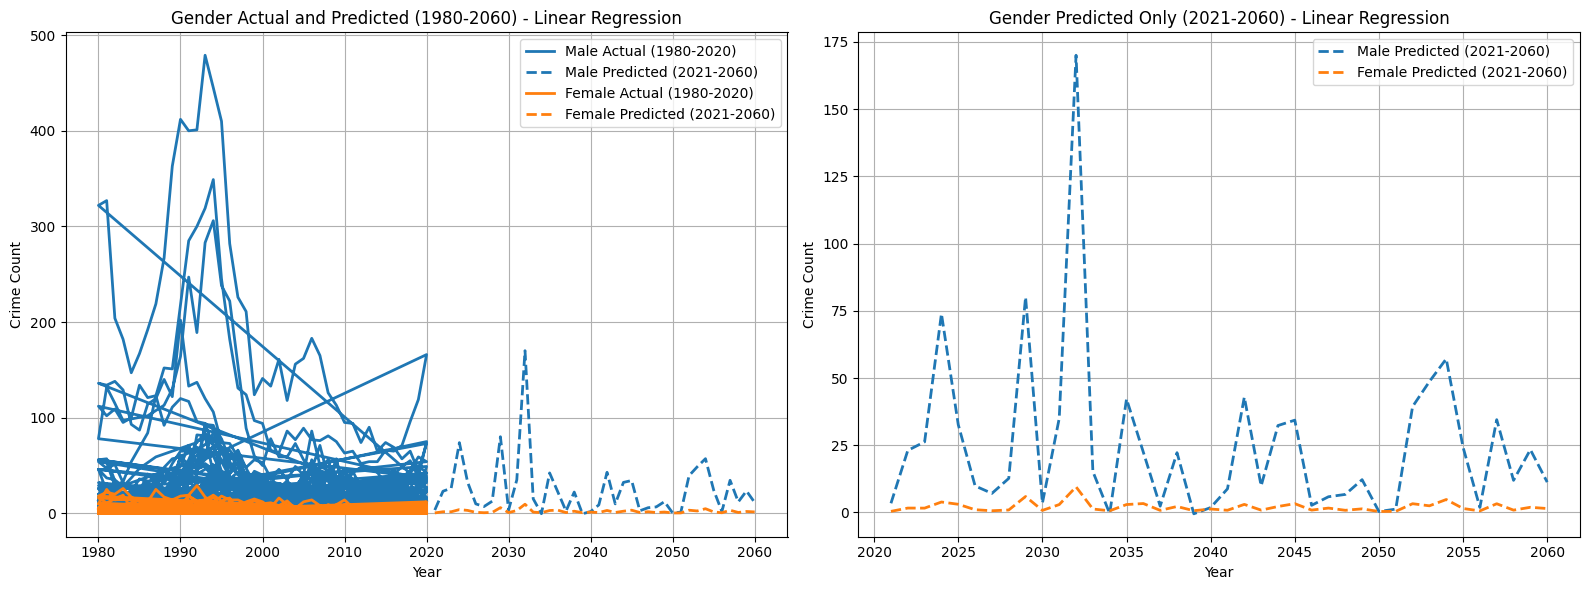


-------------------- Category: Race --------------------
Targets: ['White', 'Black', 'Amer. Indian/Alaskan Native', 'Asian/Nat. Hawaiian/Pac Isl']
------------------------------------------------------------


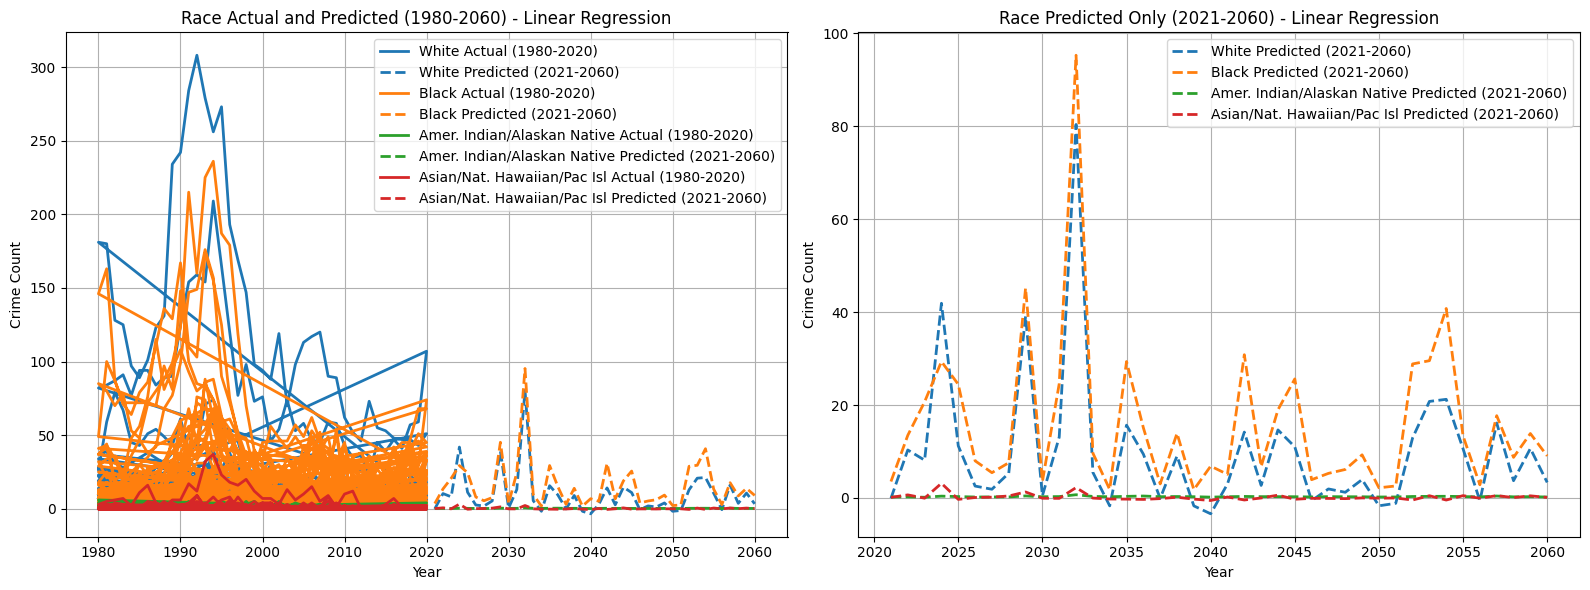


-------------------- Category: Relation --------------------
Targets: ['Family', 'Acquaintance', 'Stranger']
------------------------------------------------------------


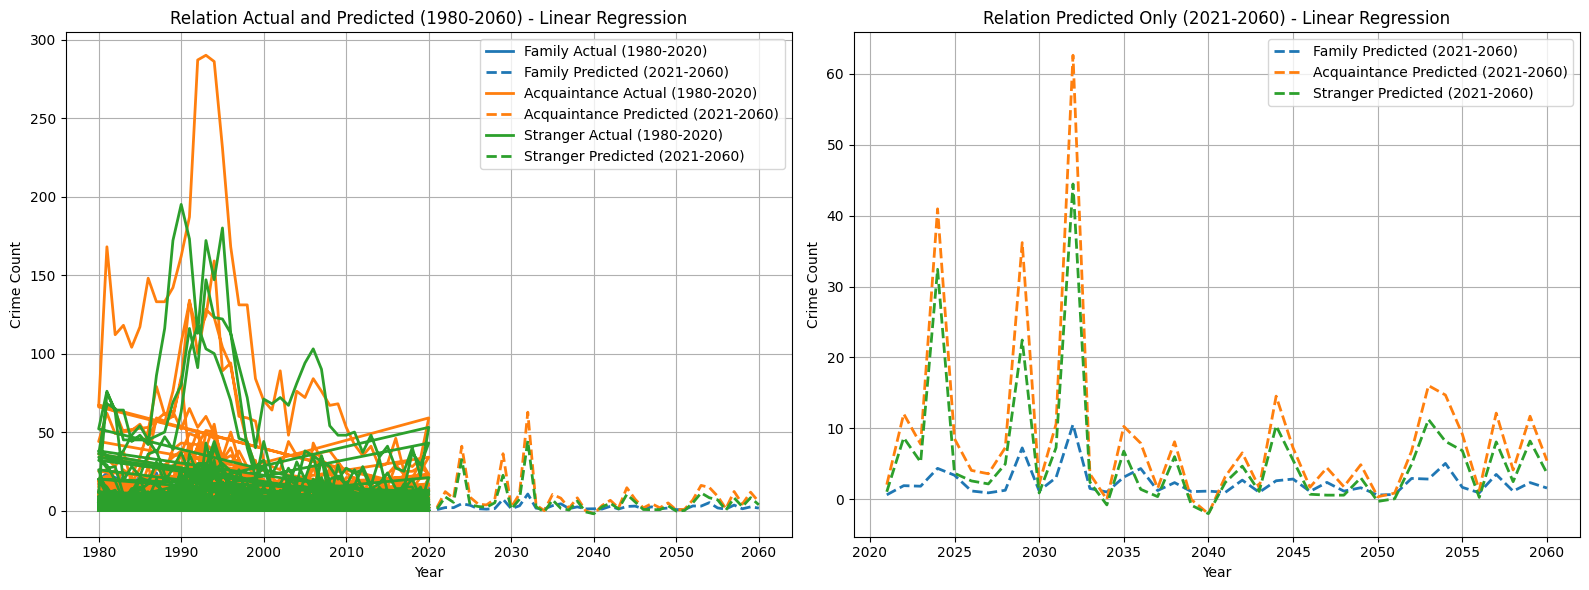


-------------------- Category: Weapon --------------------
Targets: ['Firearm', 'Knife', 'Blunt object', 'Personal']
------------------------------------------------------------


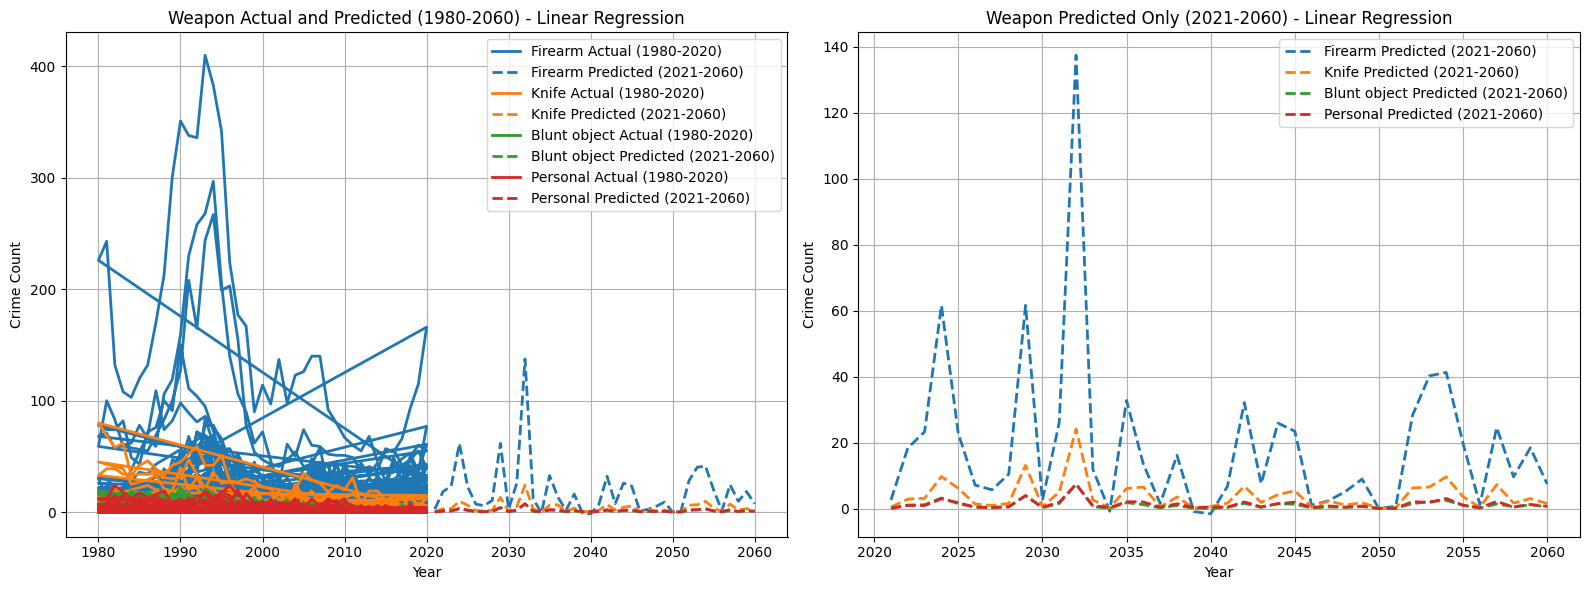


-------------------- Category: Offenders --------------------
Targets: ['One offender involved', 'Two or more offenders involved']
------------------------------------------------------------


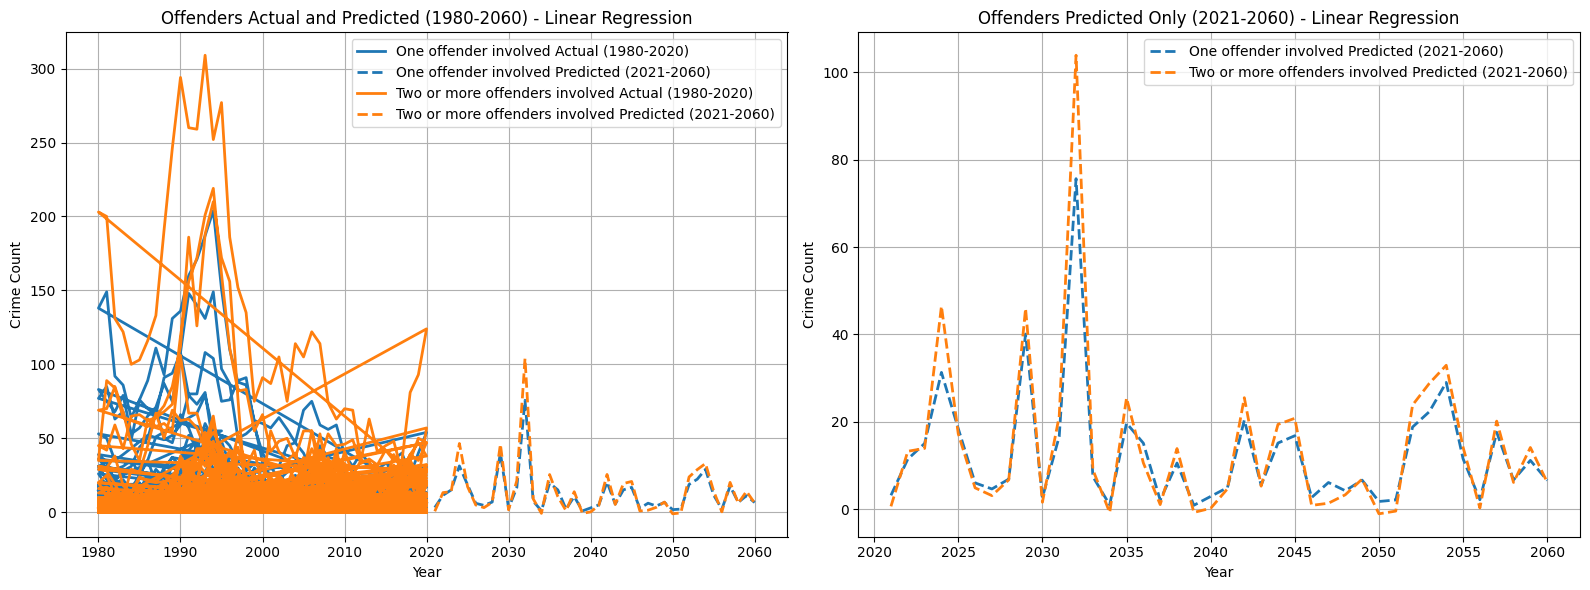

                            Target   Category              Model   MAE    MSE  \
0                             Male     Gender  Linear Regression  0.92   1.95   
1                           Female     Gender  Linear Regression  0.99   1.79   
2                            White       Race  Linear Regression  4.70  47.86   
3                            Black       Race  Linear Regression  5.00  52.43   
4      Amer. Indian/Alaskan Native       Race  Linear Regression  0.30   0.15   
5      Asian/Nat. Hawaiian/Pac Isl       Race  Linear Regression  0.42   0.54   
6                           Family   Relation  Linear Regression  1.18   2.26   
7                     Acquaintance   Relation  Linear Regression  2.15  11.37   
8                         Stranger   Relation  Linear Regression  2.22  11.83   
9                          Firearm     Weapon  Linear Regression  2.40  17.01   
10                           Knife     Weapon  Linear Regression  1.62   5.90   
11                    Blunt 

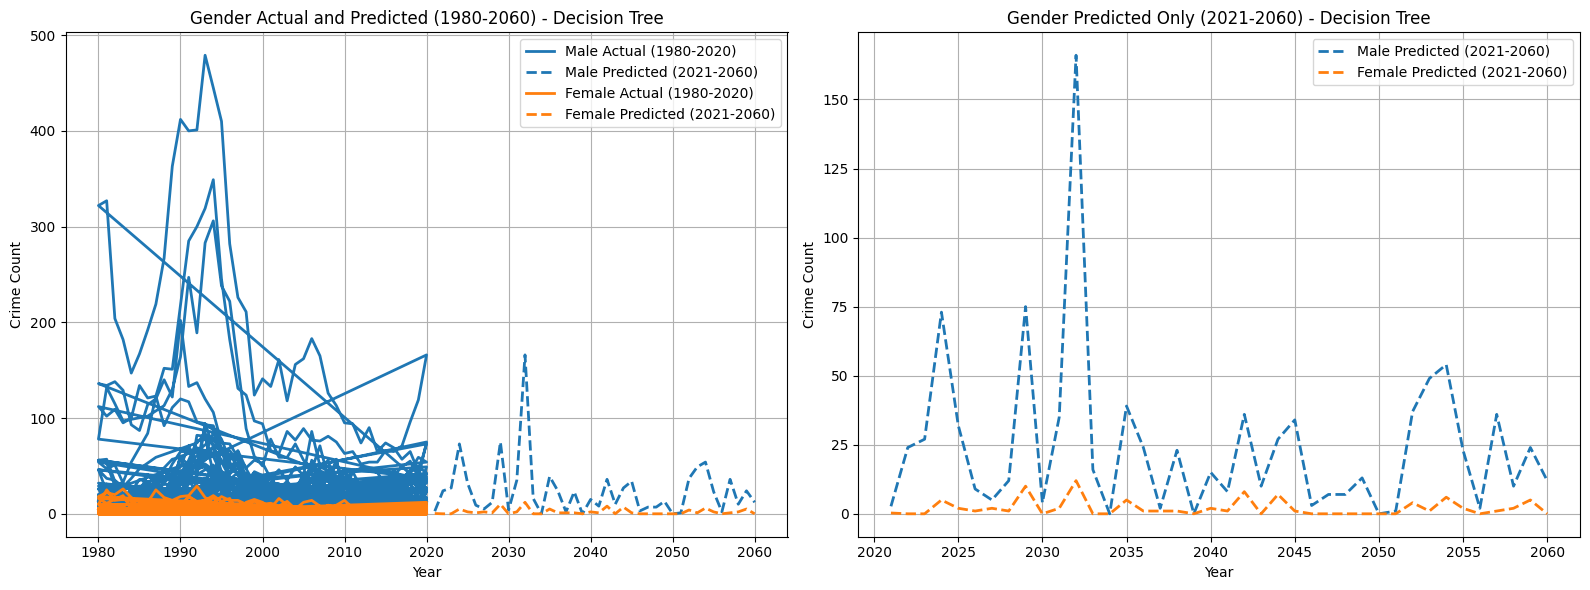


-------------------- Category: Race --------------------
Targets: ['White', 'Black', 'Amer. Indian/Alaskan Native', 'Asian/Nat. Hawaiian/Pac Isl']
------------------------------------------------------------


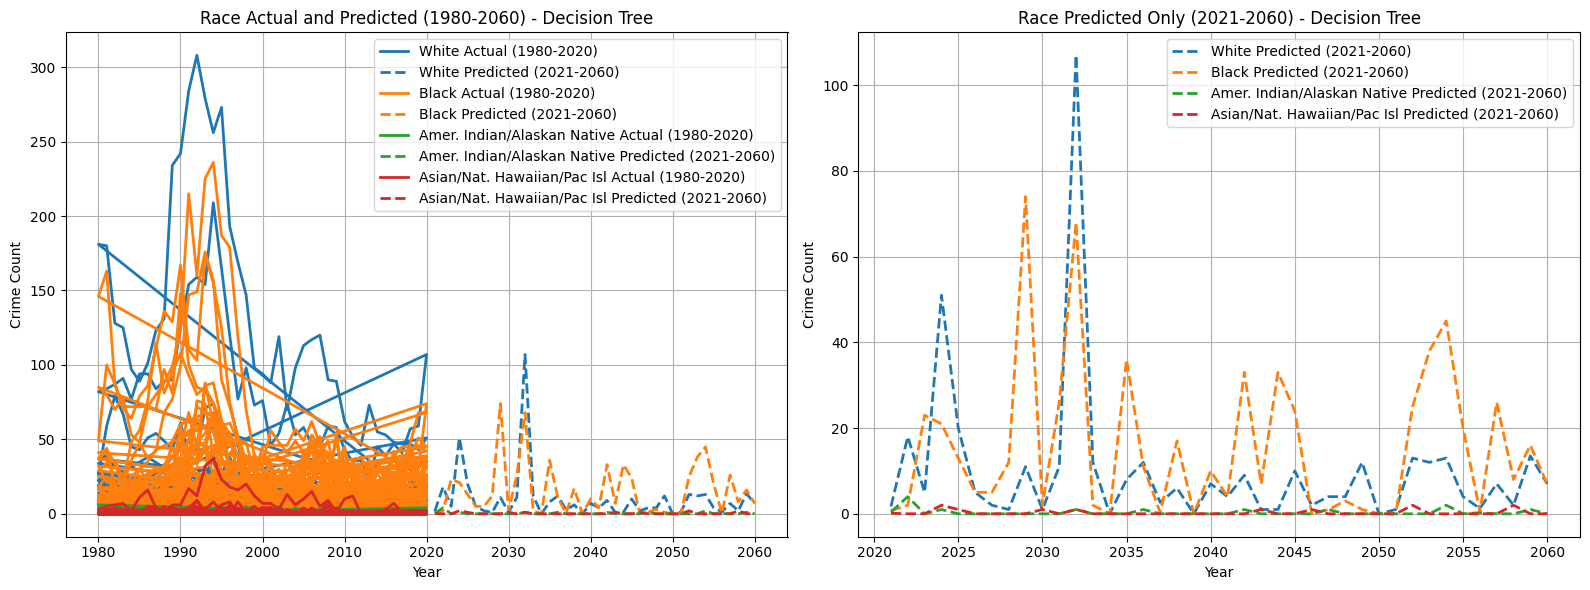


-------------------- Category: Relation --------------------
Targets: ['Family', 'Acquaintance', 'Stranger']
------------------------------------------------------------


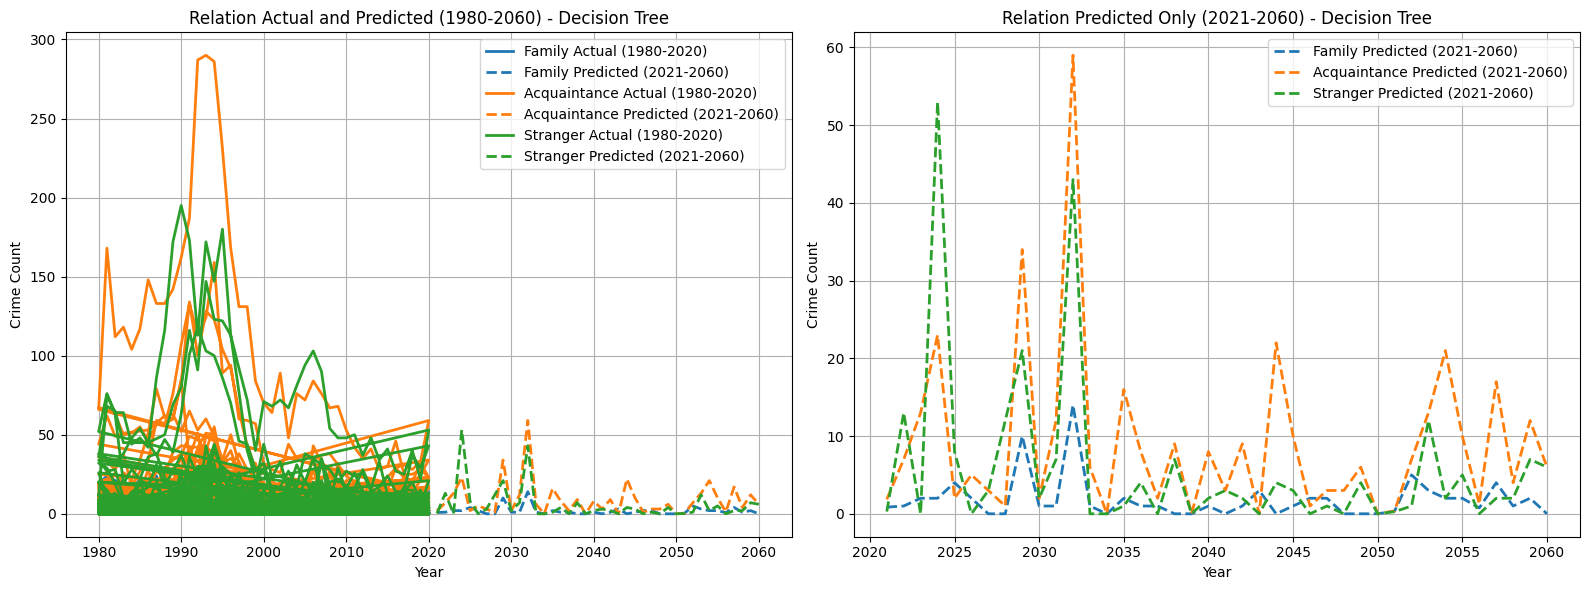


-------------------- Category: Weapon --------------------
Targets: ['Firearm', 'Knife', 'Blunt object', 'Personal']
------------------------------------------------------------


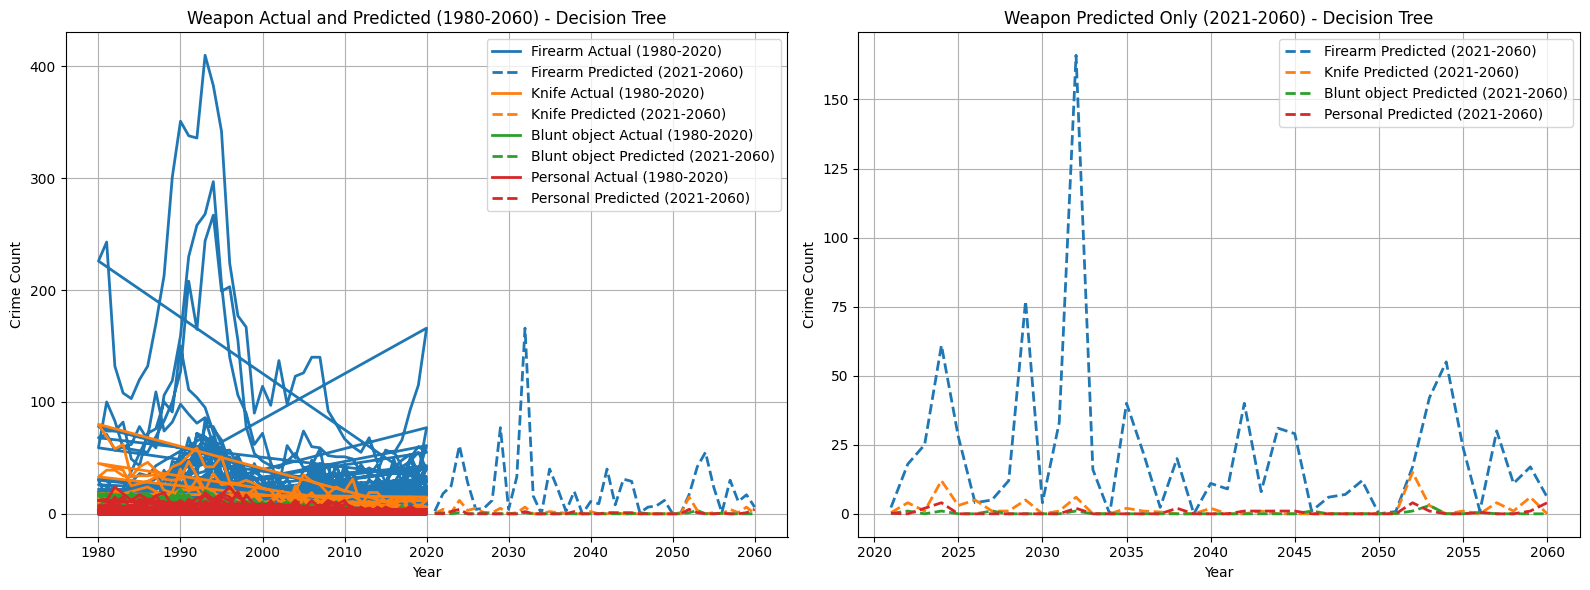


-------------------- Category: Offenders --------------------
Targets: ['One offender involved', 'Two or more offenders involved']
------------------------------------------------------------


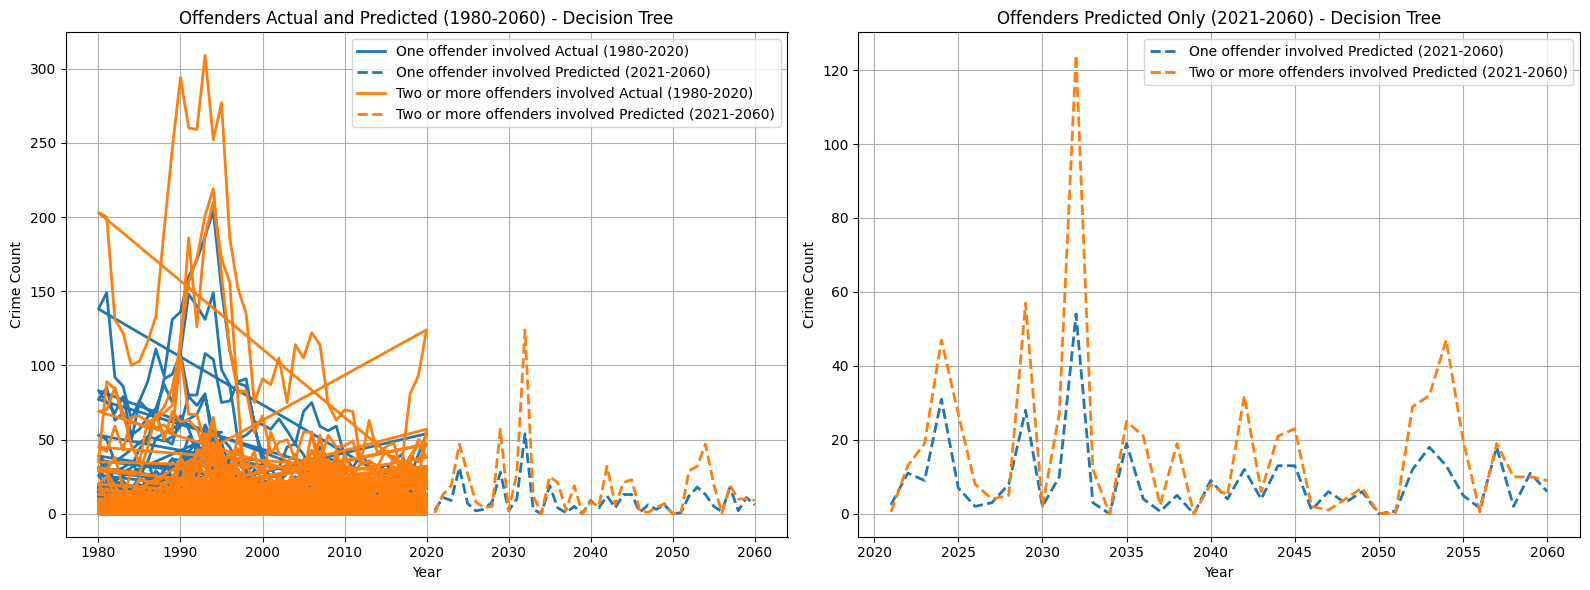

                            Target   Category          Model   MAE    MSE  \
0                             Male     Gender  Decision Tree  1.27   4.97   
1                           Female     Gender  Decision Tree  1.26   4.03   
2                            White       Race  Decision Tree  3.48  34.97   
3                            Black       Race  Decision Tree  3.68  48.87   
4      Amer. Indian/Alaskan Native       Race  Decision Tree  0.62   1.54   
5      Asian/Nat. Hawaiian/Pac Isl       Race  Decision Tree  0.35   1.36   
6                           Family   Relation  Decision Tree  1.38   4.25   
7                     Acquaintance   Relation  Decision Tree  3.20  27.38   
8                         Stranger   Relation  Decision Tree  2.98  25.50   
9                          Firearm     Weapon  Decision Tree  3.32  34.54   
10                           Knife     Weapon  Decision Tree  2.13  12.34   
11                    Blunt object     Weapon  Decision Tree  1.36   6.61   

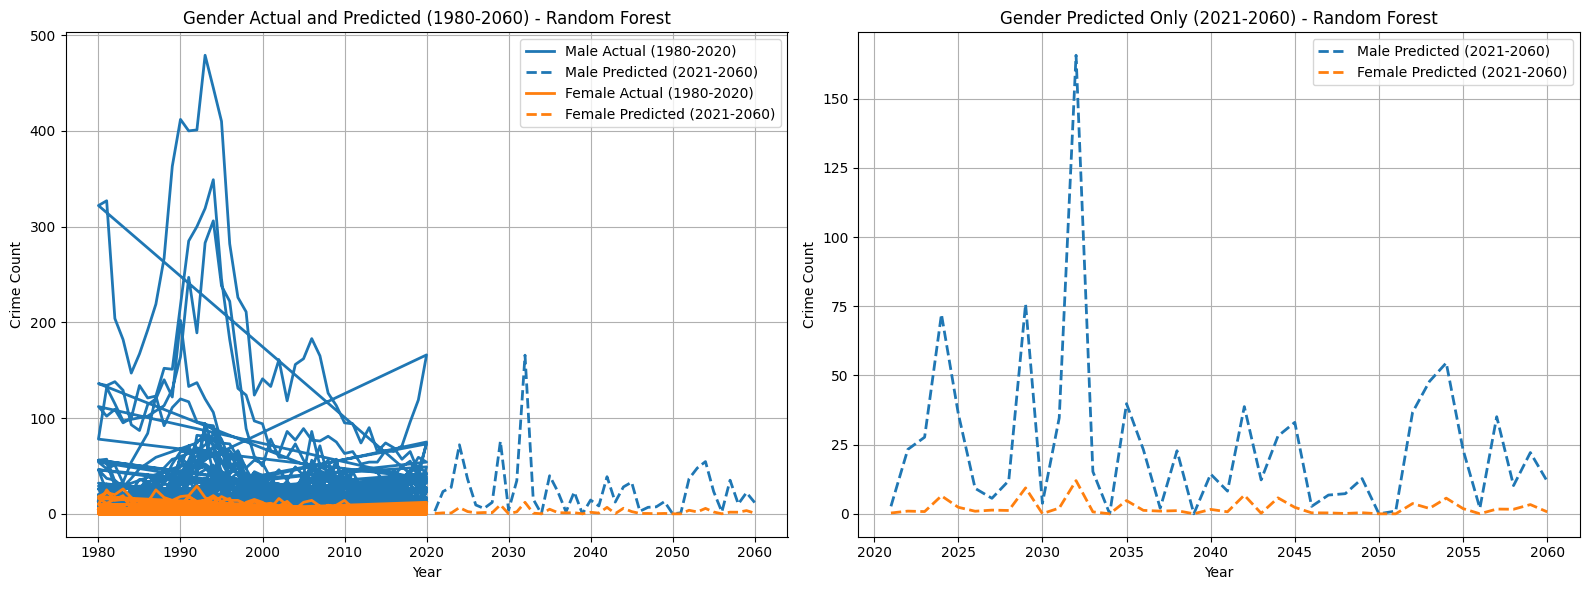


-------------------- Category: Race --------------------
Targets: ['White', 'Black', 'Amer. Indian/Alaskan Native', 'Asian/Nat. Hawaiian/Pac Isl']
------------------------------------------------------------


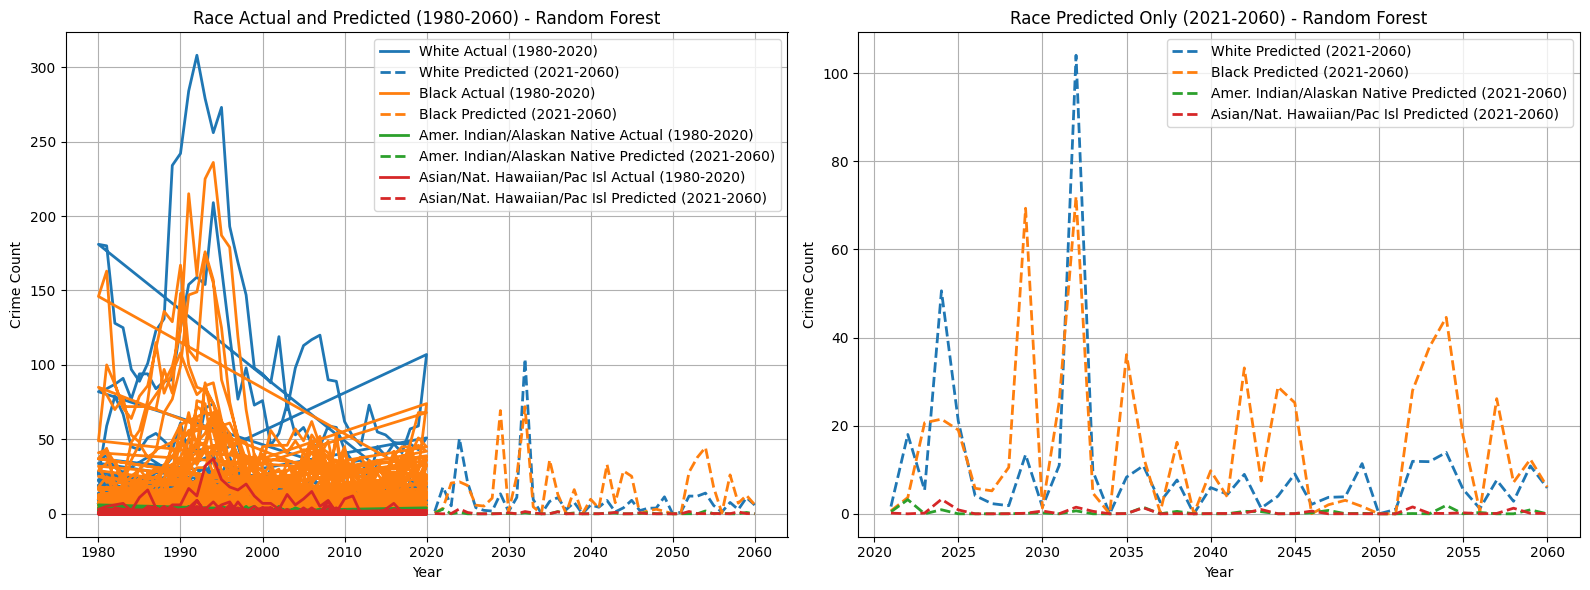


-------------------- Category: Relation --------------------
Targets: ['Family', 'Acquaintance', 'Stranger']
------------------------------------------------------------


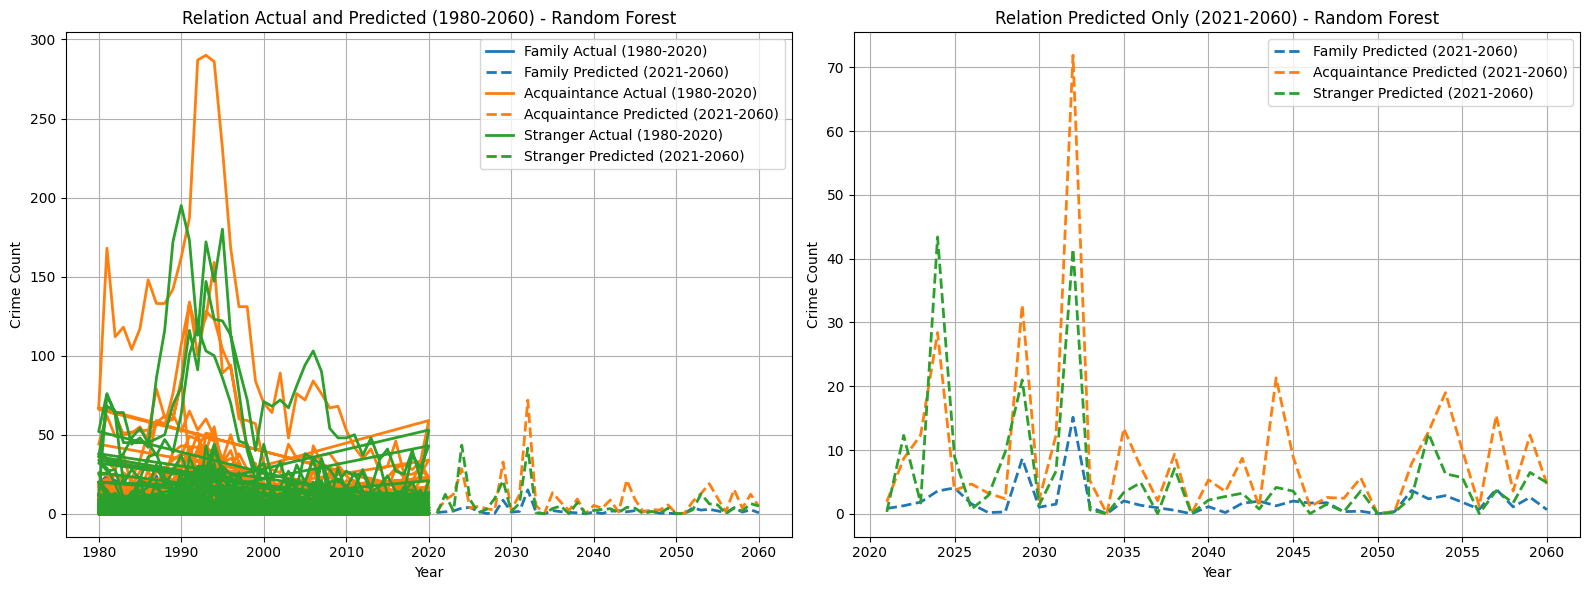


-------------------- Category: Weapon --------------------
Targets: ['Firearm', 'Knife', 'Blunt object', 'Personal']
------------------------------------------------------------


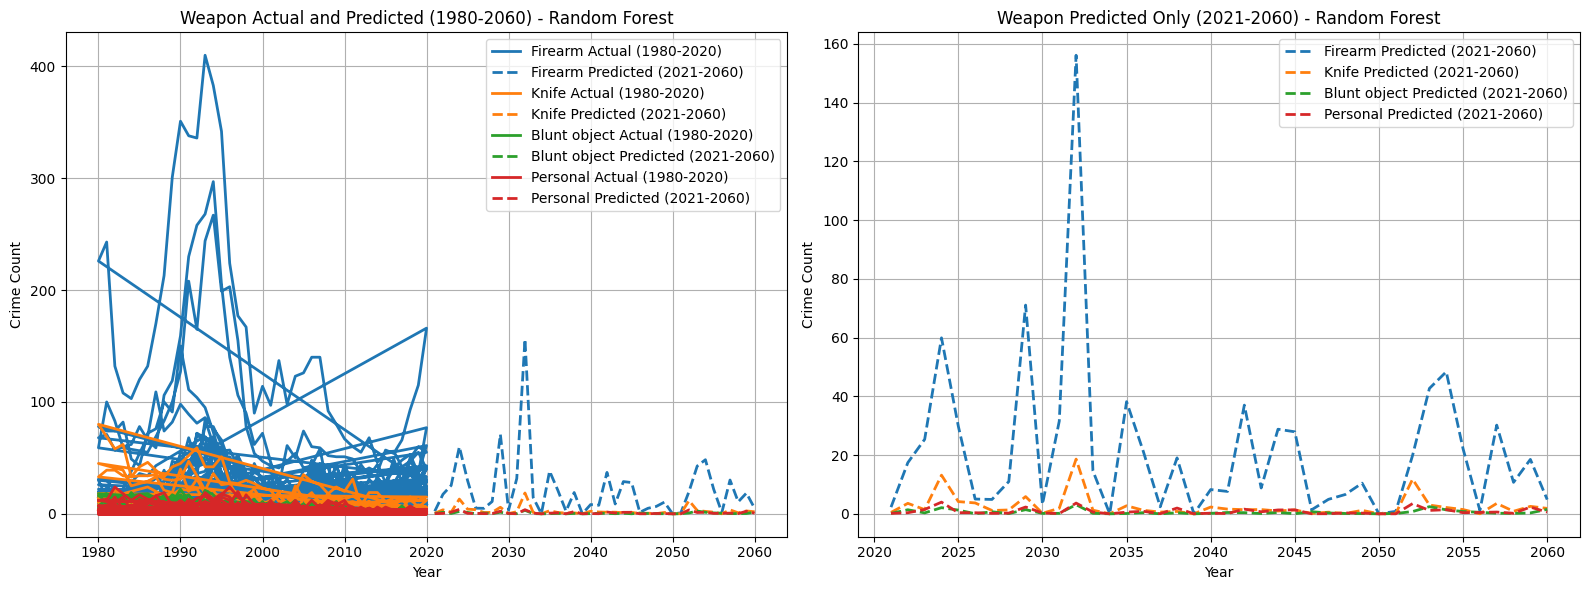


-------------------- Category: Offenders --------------------
Targets: ['One offender involved', 'Two or more offenders involved']
------------------------------------------------------------


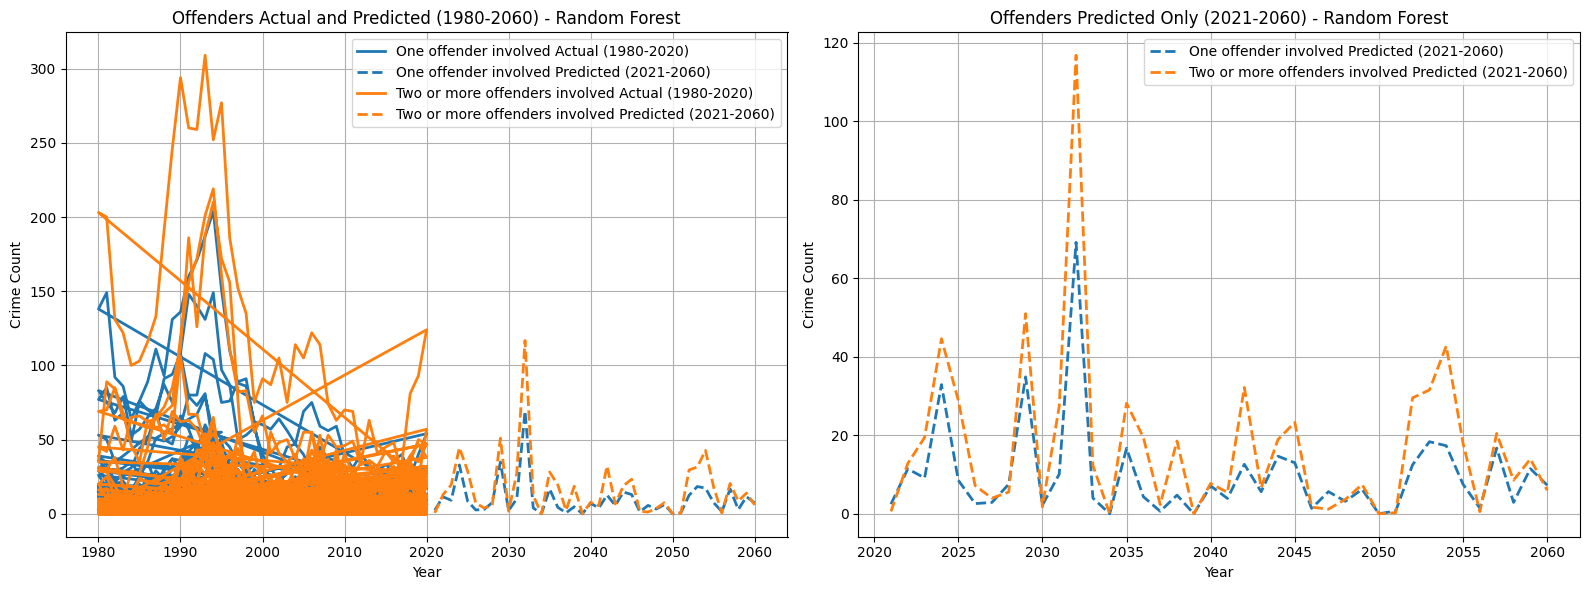

                            Target   Category          Model   MAE    MSE  \
0                             Male     Gender  Random Forest  1.42   7.38   
1                           Female     Gender  Random Forest  1.02   2.34   
2                            White       Race  Random Forest  2.70  18.56   
3                            Black       Race  Random Forest  2.58  15.20   
4      Amer. Indian/Alaskan Native       Race  Random Forest  0.45   0.51   
5      Asian/Nat. Hawaiian/Pac Isl       Race  Random Forest  0.34   0.57   
6                           Family   Relation  Random Forest  1.04   2.30   
7                     Acquaintance   Relation  Random Forest  2.55  16.30   
8                         Stranger   Relation  Random Forest  2.39  13.53   
9                          Firearm     Weapon  Random Forest  2.38  16.64   
10                           Knife     Weapon  Random Forest  1.55   5.50   
11                    Blunt object     Weapon  Random Forest  1.07   4.08   

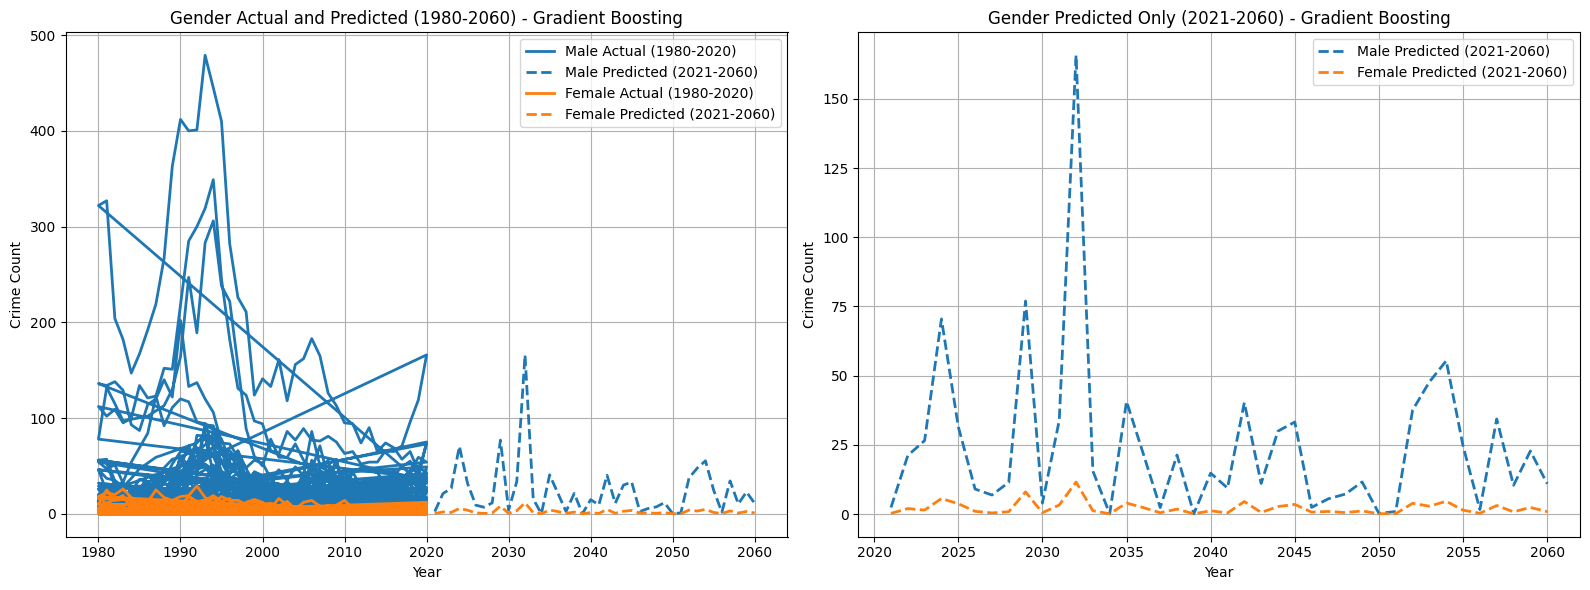


-------------------- Category: Race --------------------
Targets: ['White', 'Black', 'Amer. Indian/Alaskan Native', 'Asian/Nat. Hawaiian/Pac Isl']
------------------------------------------------------------


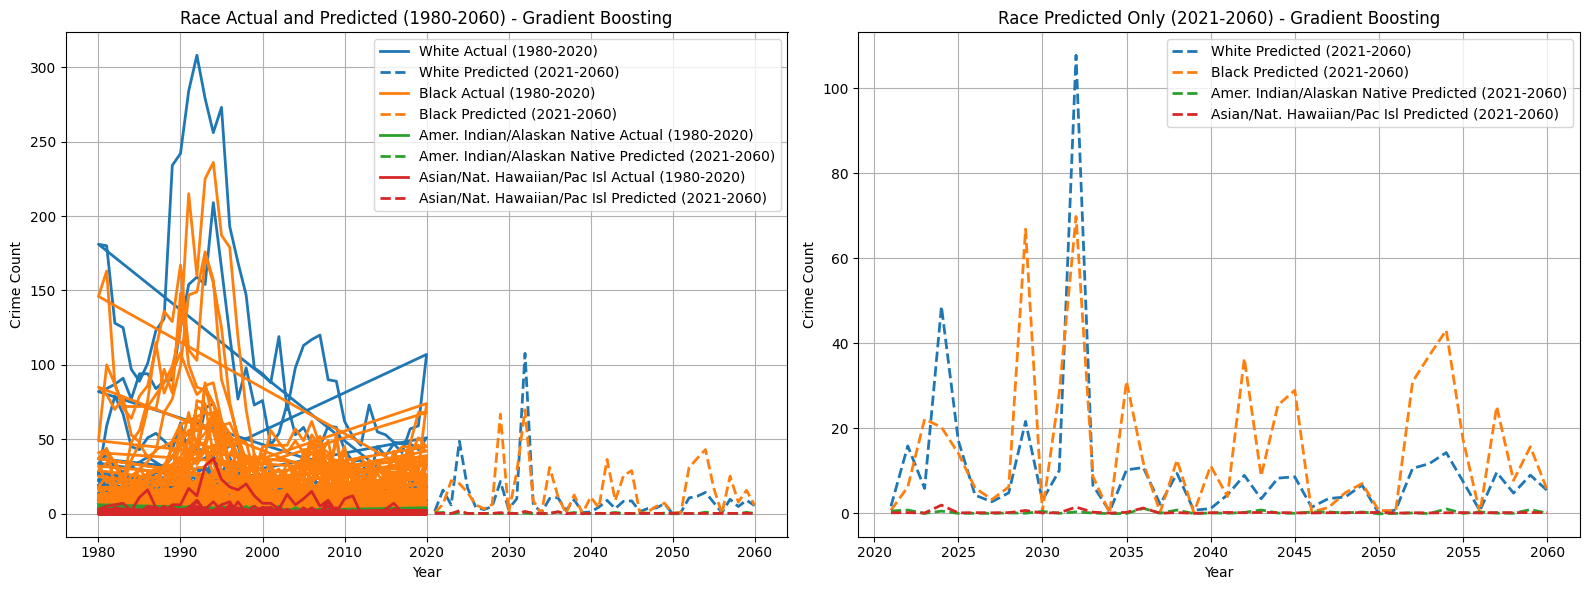


-------------------- Category: Relation --------------------
Targets: ['Family', 'Acquaintance', 'Stranger']
------------------------------------------------------------


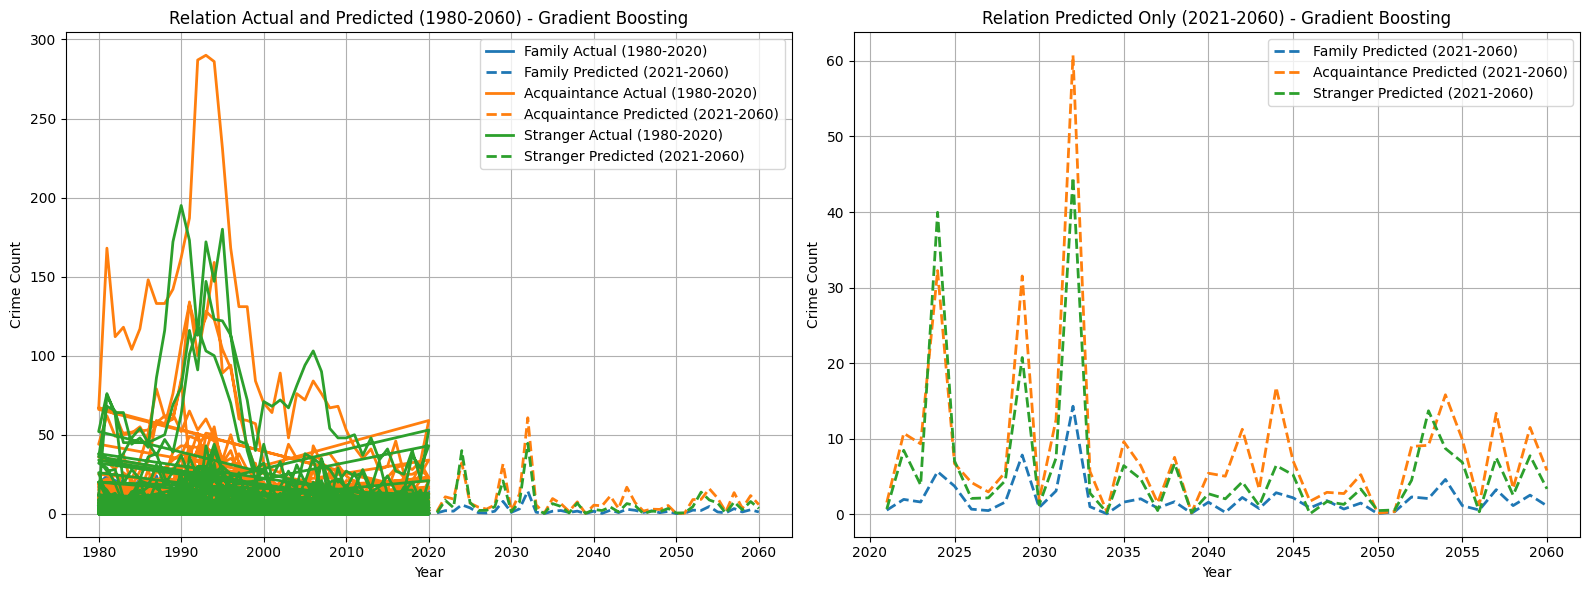


-------------------- Category: Weapon --------------------
Targets: ['Firearm', 'Knife', 'Blunt object', 'Personal']
------------------------------------------------------------


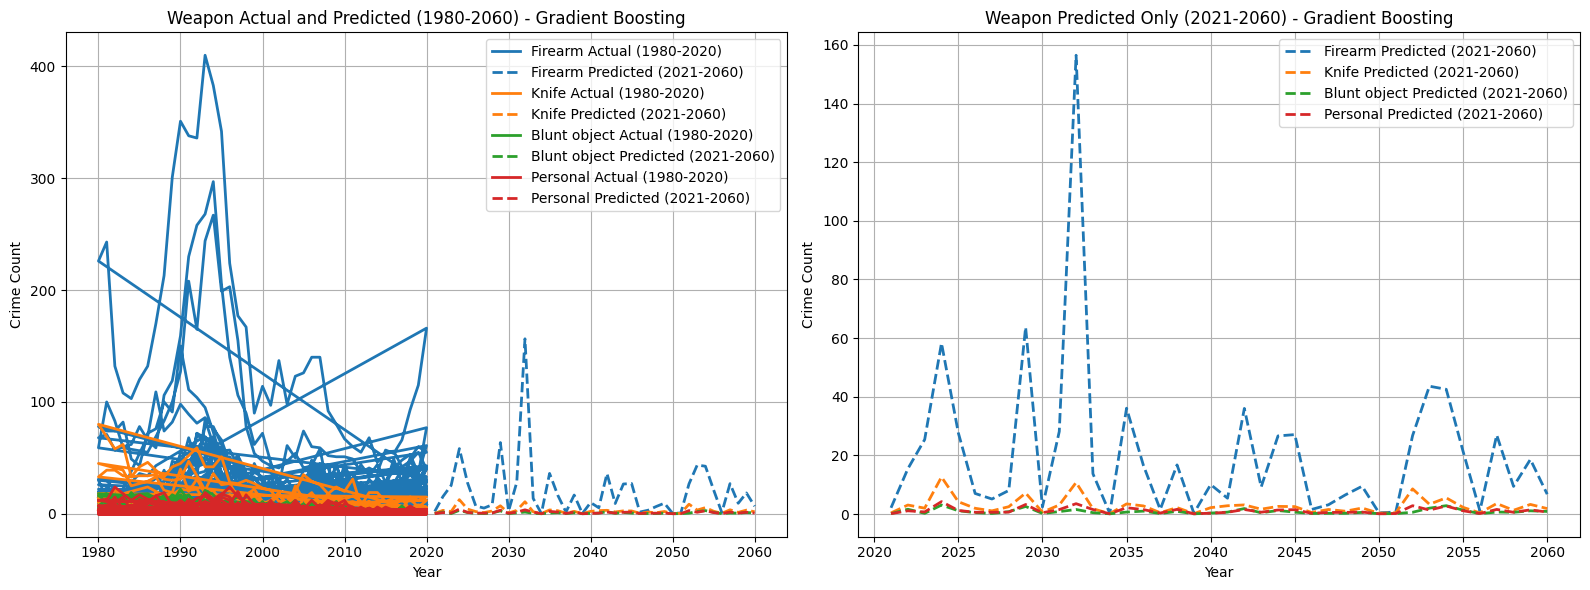


-------------------- Category: Offenders --------------------
Targets: ['One offender involved', 'Two or more offenders involved']
------------------------------------------------------------


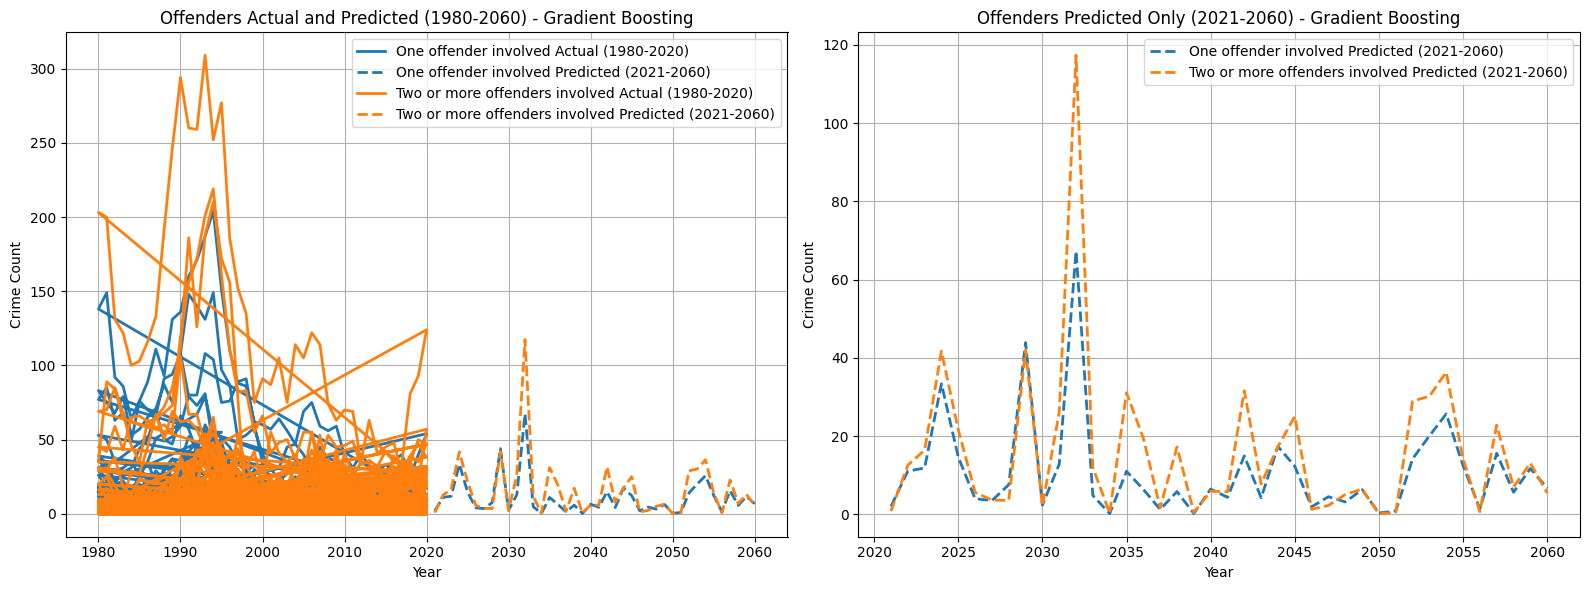

                            Target   Category              Model   MAE    MSE  \
0                             Male     Gender  Gradient Boosting  1.70   6.73   
1                           Female     Gender  Gradient Boosting  0.96   1.96   
2                            White       Race  Gradient Boosting  2.56  14.74   
3                            Black       Race  Gradient Boosting  3.10  19.55   
4      Amer. Indian/Alaskan Native       Race  Gradient Boosting  0.38   0.27   
5      Asian/Nat. Hawaiian/Pac Isl       Race  Gradient Boosting  0.30   0.41   
6                           Family   Relation  Gradient Boosting  1.09   2.20   
7                     Acquaintance   Relation  Gradient Boosting  2.66  13.83   
8                         Stranger   Relation  Gradient Boosting  2.46  13.76   
9                          Firearm     Weapon  Gradient Boosting  2.64  17.49   
10                           Knife     Weapon  Gradient Boosting  1.49   4.75   
11                    Blunt 

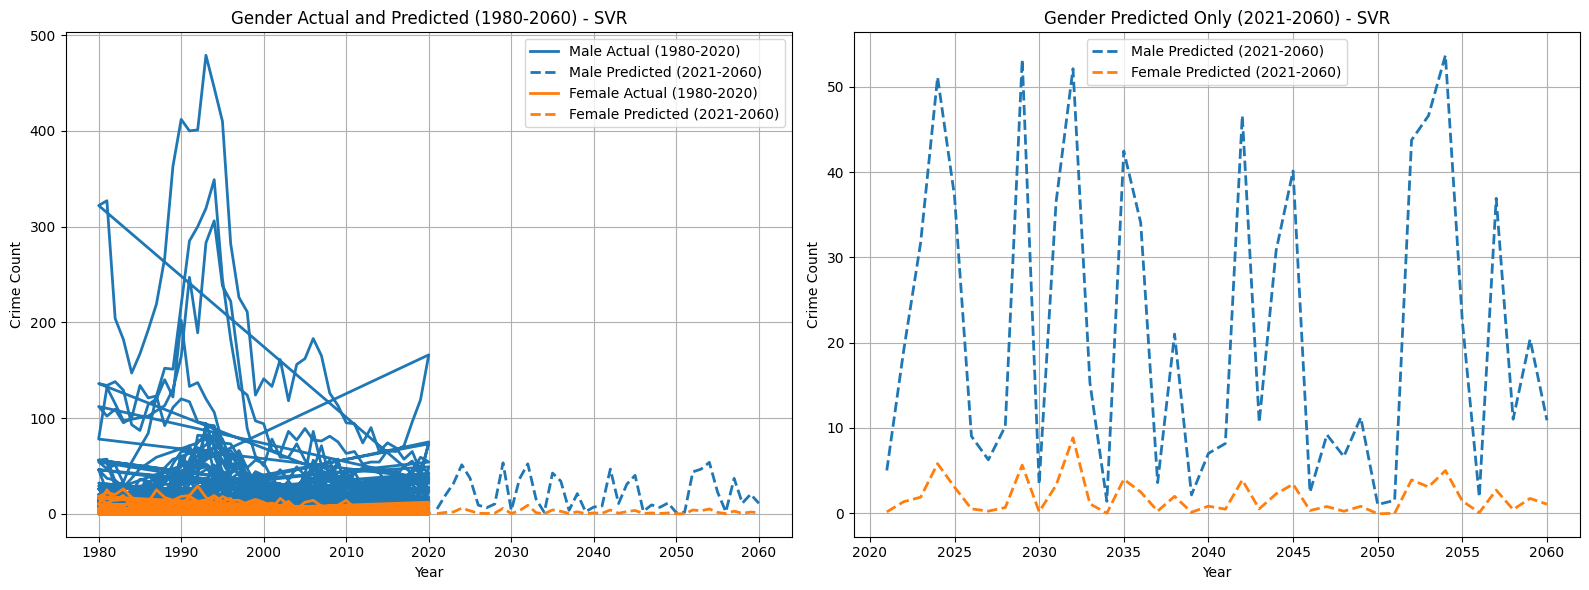


-------------------- Category: Race --------------------
Targets: ['White', 'Black', 'Amer. Indian/Alaskan Native', 'Asian/Nat. Hawaiian/Pac Isl']
------------------------------------------------------------


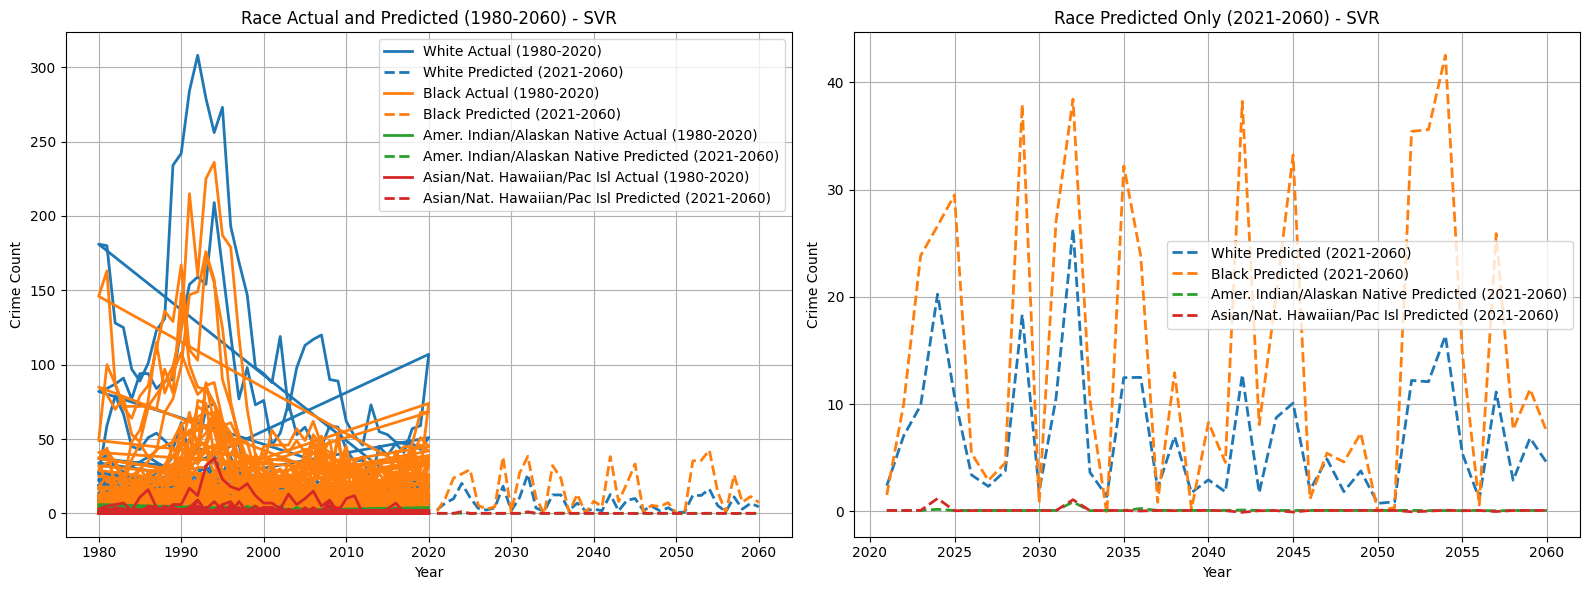


-------------------- Category: Relation --------------------
Targets: ['Family', 'Acquaintance', 'Stranger']
------------------------------------------------------------


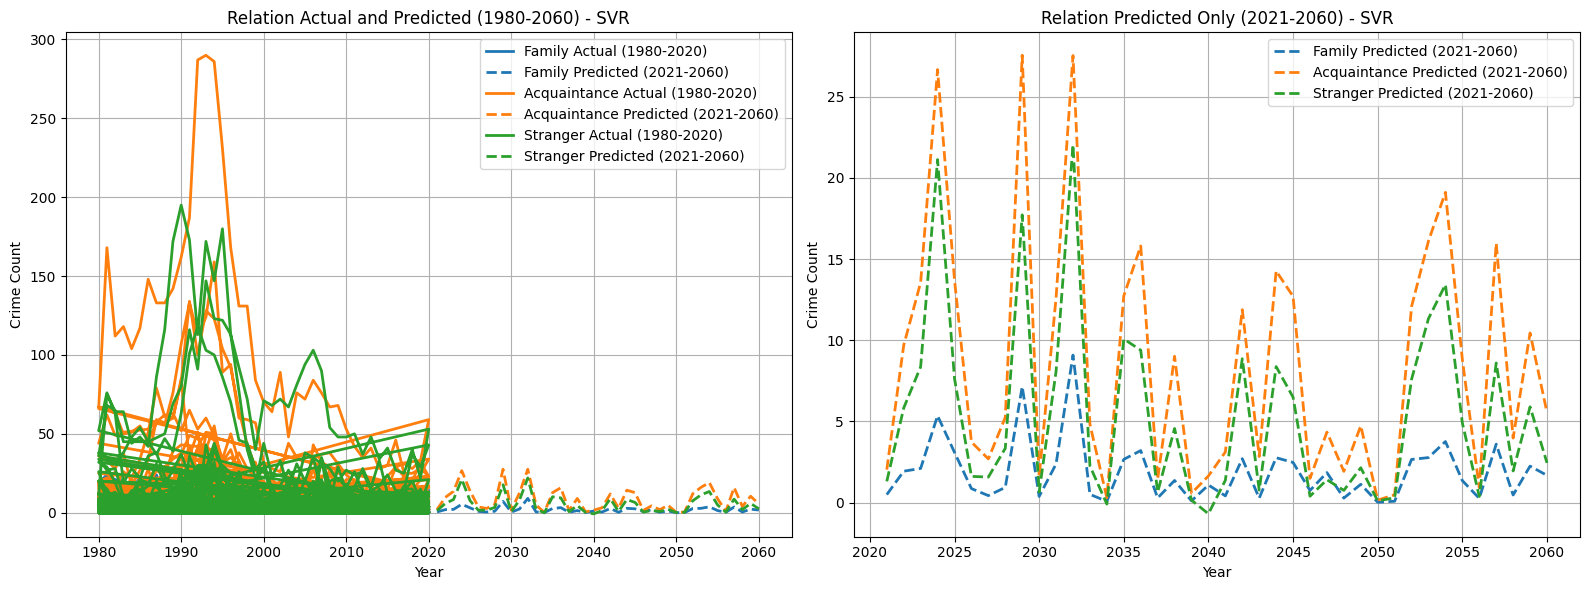


-------------------- Category: Weapon --------------------
Targets: ['Firearm', 'Knife', 'Blunt object', 'Personal']
------------------------------------------------------------


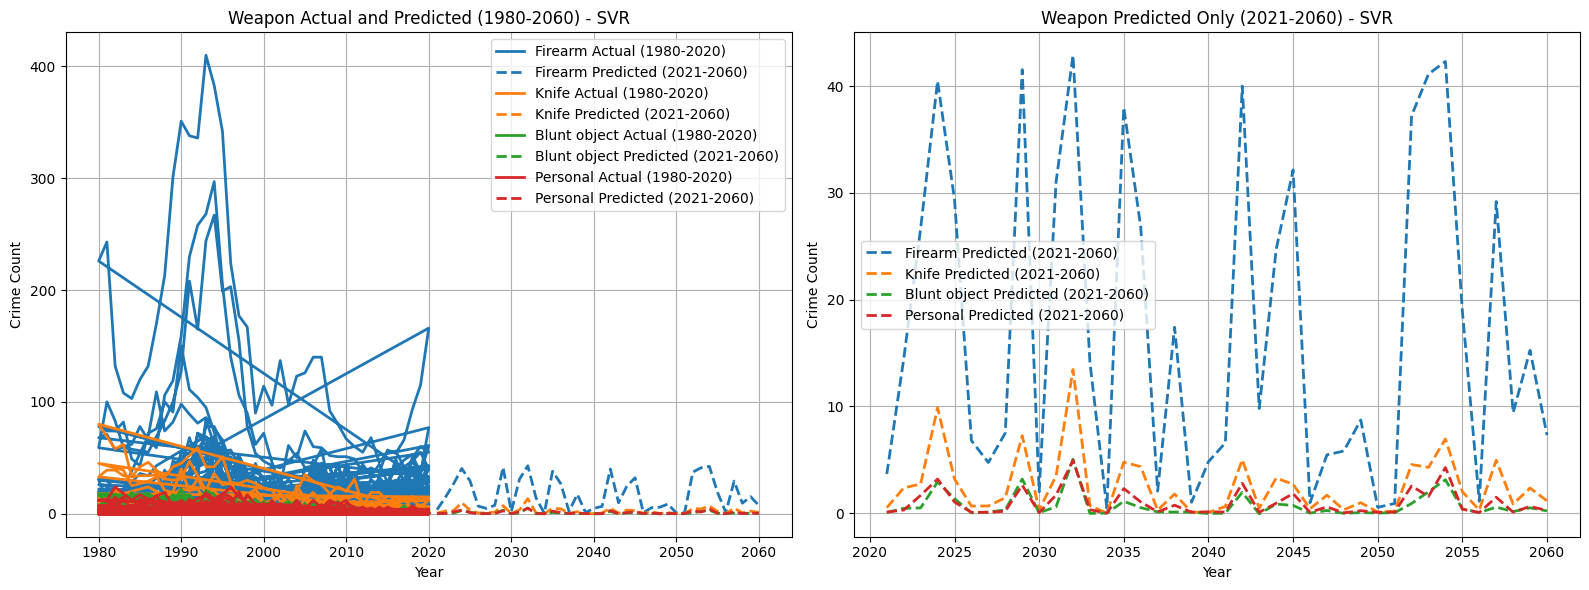


-------------------- Category: Offenders --------------------
Targets: ['One offender involved', 'Two or more offenders involved']
------------------------------------------------------------


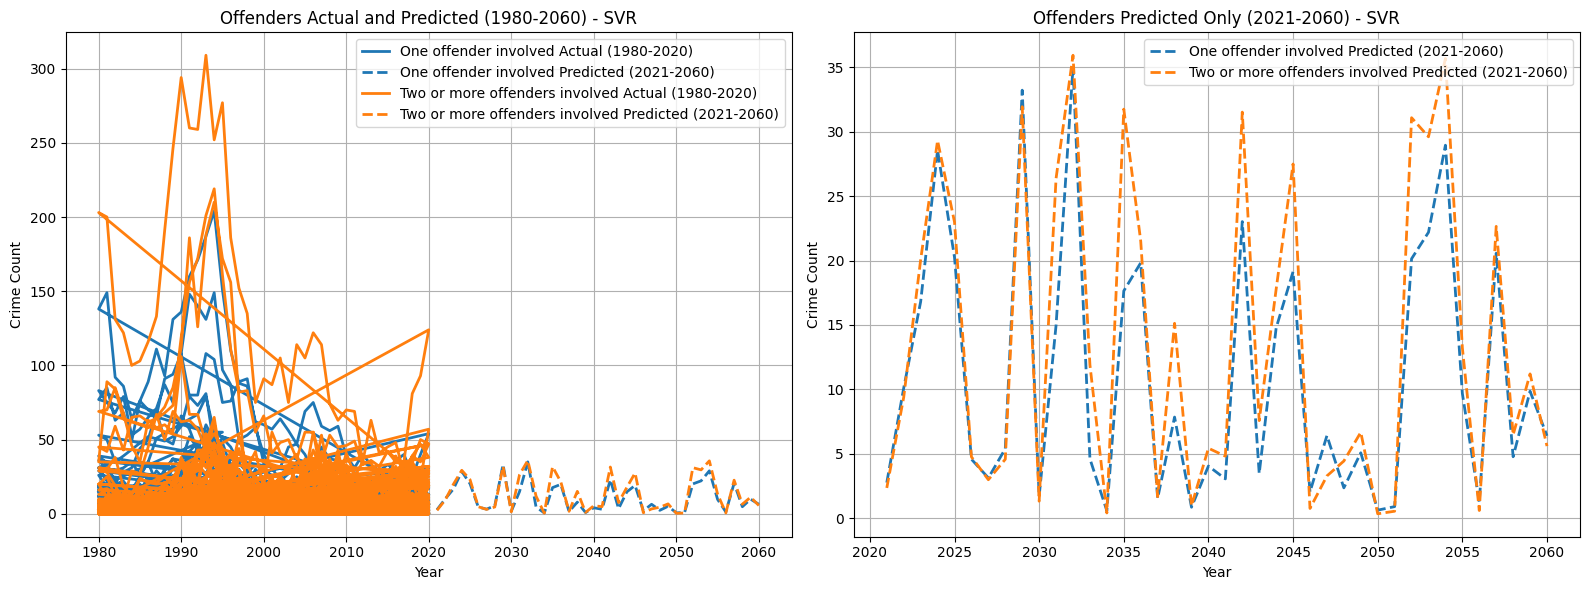

                            Target   Category Model   MAE    MSE  R2 Score
0                             Male     Gender   SVR  2.15  12.41      0.96
1                           Female     Gender   SVR  0.90   1.88      0.44
2                            White       Race   SVR  2.61  13.69      0.47
3                            Black       Race   SVR  4.28  49.84      0.79
4      Amer. Indian/Alaskan Native       Race   SVR  0.15   0.11     -0.01
5      Asian/Nat. Hawaiian/Pac Isl       Race   SVR  0.24   0.42     -0.02
6                           Family   Relation   SVR  1.07   2.30      0.46
7                     Acquaintance   Relation   SVR  2.34  14.09      0.85
8                         Stranger   Relation   SVR  2.17  13.35      0.72
9                          Firearm     Weapon   SVR  2.87  22.59      0.89
10                           Knife     Weapon   SVR  1.42   5.32      0.41
11                    Blunt object     Weapon   SVR  0.97   4.31      0.15
12                       

In [ ]:
valid_features = [col for col in features if col in raw_data.columns]
valid_features.append('Year')

# prep the future_X data
last_data = raw_data[raw_data["Year"] == 2020].drop(columns=["Year"] + all_target_columns)
future_years = pd.DataFrame({"Year": np.arange(2021, 2061)})
future_X = pd.concat([future_years, pd.DataFrame(np.tile(last_data.values, (len(future_years), 1)), columns=last_data.columns)], axis=1)
# using this to predict
future_X = future_X[valid_features]

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVR": SVR()
}

for model_name, model in models.items():

    print("="*80)
    print(f"MODEL: {model_name}")
    print("="*80)

    evaluation_results = []


    # for each target, train and predict
    for y, targets, category in zip(y_all, all_targets, all_target_names):

        print("\n" + "-"*20 + f" Category: {category} " + "-"*20)
        print(f"Targets: {targets}")
        print("-"*60)

        # split data (80% training, 20% testing)
        train_size = int(len(raw_data) * 0.8)
        X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
        y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

        # normalize features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # train on random forest
        target_models = {}
        for target in targets:
            model_instance = clone(model)
            model_instance.fit(X_train_scaled, y_train[target])
            target_models[target] = model_instance

        # evaluate model
        for target, model_instance in target_models.items():
            y_pred = model_instance.predict(X_test_scaled)
            mae = mean_absolute_error(y_test[target], y_pred)
            mse = mean_squared_error(y_test[target], y_pred)
            r2 = r2_score(y_test[target], y_pred)

            evaluation_results.append({
                "Target": target,
                "Category": category,
                "Model": model_name,
                "MAE": round(mae, 2),
                "MSE": round(mse, 2),
                "R2 Score": round(r2, 2)
            })


        # now predict future values (2021-2060)
        future_X_scaled = scaler.transform(future_X[features])
        future_predictions = {target: model_instance.predict(future_X_scaled) for target, model_instance in target_models.items()}

        
        # PLOT
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns, adjust figsize as needed

        # --- Left plot: Actual and Predicted ---
        for target in targets:
            color = plt.cm.tab10(targets.index(target) % 10)
            actual_data = raw_data[target]
            if actual_data.ndim > 1:
                actual_data = actual_data.mean(axis=1)
            axes[0].plot(raw_data["Year"], actual_data, label=f"{target} Actual (1980-2020)", color=color, linewidth=2)

            target_predictions = future_predictions[target]
            if target_predictions.ndim > 1:
                target_predictions = target_predictions.mean(axis=1)
            if target_predictions.shape[0] != 40:
                target_predictions = target_predictions[:40]
            axes[0].plot(np.arange(2021, 2061), target_predictions, linestyle="dashed", label=f"{target} Predicted (2021-2060)", color=color, linewidth=2)

        axes[0].set_xlabel("Year")
        axes[0].set_ylabel("Crime Count")
        axes[0].set_title(f"{category} Actual and Predicted (1980-2060) - {model_name}")
        axes[0].legend()
        axes[0].grid(True)

        # --- Right plot: Future Predictions Only ---
        for target in targets:
            target_predictions = future_predictions[target]
            if target_predictions.ndim > 1:
                target_predictions = target_predictions.mean(axis=1)
            if target_predictions.shape[0] != 40:
                target_predictions = target_predictions[:40]
            axes[1].plot(np.arange(2021, 2061), target_predictions, linestyle="dashed", label=f"{target} Predicted (2021-2060)", linewidth=2)

        axes[1].set_xlabel("Year")
        axes[1].set_ylabel("Crime Count")
        axes[1].set_title(f"{category} Predicted Only (2021-2060) - {model_name}")
        axes[1].legend()
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()
    
    # print evaulation table of model
    eval_df = pd.DataFrame(evaluation_results)
    print(eval_df)









Model Evaluation
--------------------

In [14]:
# Evaluate and compare different classification models on the dataset

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import clone

# show all rows in the dataset
pd.set_option('display.max_rows', None)

# Prepare valid features from raw_data
valid_features = [col for col in features if col in raw_data.columns]
valid_features.append('Year')

# Define a dictionary of classification models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVC": SVC()
}

evaluation_results = []

for model_name, model in models.items():

    # For each target, train and predict
    for y, targets, category in zip(y_all, all_targets, all_target_names):

        # Split data into 80% training and 20% testing
        train_size = int(len(raw_data) * 0.8)
        X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
        y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

        # Normalize features using StandardScaler
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Train one model per target in the current category
        target_models = {}
        for target in targets:
            model_instance = clone(model)
            model_instance.fit(X_train_scaled, y_train[target])
            target_models[target] = model_instance

        # Evaluate model on test data
        for target, model_instance in target_models.items():
            y_pred = model_instance.predict(X_test_scaled)
            acc = accuracy_score(y_test[target], y_pred)
            prec = precision_score(y_test[target], y_pred, average='weighted', zero_division=0)
            rec = recall_score(y_test[target], y_pred, average='weighted', zero_division=0)
            f1 = f1_score(y_test[target], y_pred, average='weighted', zero_division=0)

            evaluation_results.append({
                "Target": target,
                "Category": category,
                "Model": model_name,
                "Accuracy": round(acc, 2),
                "Precision": round(prec, 2),
                "Recall": round(rec, 2),
                "F1-Score": round(f1, 2)
            })

# Convert the evaluation_results list to a DataFrame and print it
eval_df = pd.DataFrame(evaluation_results)
print(eval_df)




                            Target   Category                Model  Accuracy  \
0                             Male     Gender  Logistic Regression      0.14   
1                           Female     Gender  Logistic Regression      0.50   
2                            White       Race  Logistic Regression      0.20   
3                            Black       Race  Logistic Regression      0.32   
4      Amer. Indian/Alaskan Native       Race  Logistic Regression      0.95   
5      Asian/Nat. Hawaiian/Pac Isl       Race  Logistic Regression      0.91   
6                           Family   Relation  Logistic Regression      0.42   
7                     Acquaintance   Relation  Logistic Regression      0.24   
8                         Stranger   Relation  Logistic Regression      0.33   
9                          Firearm     Weapon  Logistic Regression      0.21   
10                           Knife     Weapon  Logistic Regression      0.39   
11                    Blunt object     W